# 유방암 진단셋을 활용한 이진분류 (모델 클래스화)

1. 데이터셋 불러오기

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch

plt.rcParams["font.family"] = "Malgun Gothic"


plt.rcParams["axes.unicode_minus"] = False

In [2]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

cancer

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [3]:
print(cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [4]:
cancer.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [5]:
cancer.data

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30))

In [6]:
cancer.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [7]:
df = pd.DataFrame(cancer.data,columns=cancer.feature_names) # 행과 행 이름 넣어 DataFrame
df['target'] = cancer.target
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [8]:
# sns.pairplot(df[['target'] + list(df.columns[:10])]) # 상관관계
# plt.show()

In [9]:
# sns.pairplot(df[['target'] + list(df.columns[10:20])]) # 상관관계
# plt.show()

In [10]:
# sns.pairplot(df[['target'] + list(df.columns[20:30])])
# plt.show()

In [11]:
# data = torch.from_numpy(df.values).float() # DataFrame의 값들만 Numpy 배열 -> Pytorch FloatTensor 형태로 변환
data = torch.from_numpy(df.drop('target', axis=1).values).float() # DataFrame의 값들만 Numpy 배열 -> Pytorch FloatTensor 형태로 변환

data.shape


C:\Users\lsm15\AppData\Local\Temp\ipykernel_32100\3282219004.py:2: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  data = torch.from_numpy(df.drop('target', axis=1).values).float() # DataFrame의 값들만 Numpy 배열 -> Pytorch FloatTensor 형태로 변환


torch.Size([569, 30])

In [12]:
# 입력값 x와 정답값 y 분리 (2차원 배열 형태 유지 : 슬라이싱)

# x = data[:, :-1]
# y = data[:, -1:]
x = data
y = torch.from_numpy(df['target'].values).float().reshape(-1,1)

print(x.size(),y.size()) # [569,30] [569,1]

torch.Size([569, 30]) torch.Size([569, 1])


In [13]:
# 학습 하이퍼파라미터 설정
n_epochs = 20000      # 학습 반복 횟수
learning_rate = 1e-3  # 학습률 0.001
print_interval = 1000 # loss 출력 횟수

In [14]:
import torch.nn as nn

# 단층 퍼셉트론 모델 클래스 (nn.Module을 상속) : 입력 -> 선형 변환(단층) -> 활성화함수
class MyModel(nn.Module):

    def __init__(self, input_dim, output_dim):
        self.input_dim = input_dim    # 입력 특성 차원수
        self.output_dim = output_dim  # 출력 차원 수 (노드)

        super().__init__() # 상속받은 nn.Module을 초기화

        self.linear = nn.Linear(input_dim, output_dim) # 입력 -> 출력 선형 변환
        # self.act = nn.Sigmoid() # 출력값을 0~1 변환 이진분류 출력층 활성화 함수

    def forward(self, x):
        y = self.linear(x)  # 선형변환 후 로직 출력

        return y

In [15]:
x.size()

torch.Size([569, 30])

In [16]:
y.size()

torch.Size([569, 1])

In [17]:
import torch.optim as optim
model = MyModel(input_dim=x.size(-1), output_dim=y.size(-1))

criterion = nn.BCEWithLogitsLoss() # 이진 분류용 손실 함수
optimizer = optim.Adam(
    model.parameters(),  # 업데이트 할 값 (모델의 가중치, 편향)
    lr=learning_rate     # 학습률
)

In [18]:
for i in range(n_epochs):
    y_hat = model(x)
    loss = criterion(y_hat,y)

    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

    if (i + 1) % print_interval == 0:
        print(f"Epoch {i + 1} loss : {loss.item():.4f}")

Epoch 1000 loss : 0.2972
Epoch 2000 loss : 0.1595
Epoch 3000 loss : 0.1332
Epoch 4000 loss : 0.1163
Epoch 5000 loss : 0.1036
Epoch 6000 loss : 0.0945
Epoch 7000 loss : 0.0879
Epoch 8000 loss : 0.0829
Epoch 9000 loss : 0.0789
Epoch 10000 loss : 0.0755
Epoch 11000 loss : 0.0726
Epoch 12000 loss : 0.0703
Epoch 13000 loss : 0.0679
Epoch 14000 loss : 0.0661
Epoch 15000 loss : 0.0641
Epoch 16000 loss : 0.0625
Epoch 17000 loss : 0.0610
Epoch 18000 loss : 0.0597
Epoch 19000 loss : 0.0584
Epoch 20000 loss : 0.0573


In [19]:
correct_cnt = (y == (y_hat > 0.5)).sum()
total_cnt = float(y.size(0))

print(f"정확도 : {correct_cnt/total_cnt*100}%")

정확도 : 98.06678009033203%


In [20]:
model.eval()

with torch.no_grad():
    probs = torch.sigmoid(y_hat)

과제
1. 상관관계가 있는 컬럼만 선택해서 사용해본다.
2. 스케일링 작업을 해서 모델의 성능을 높인다.

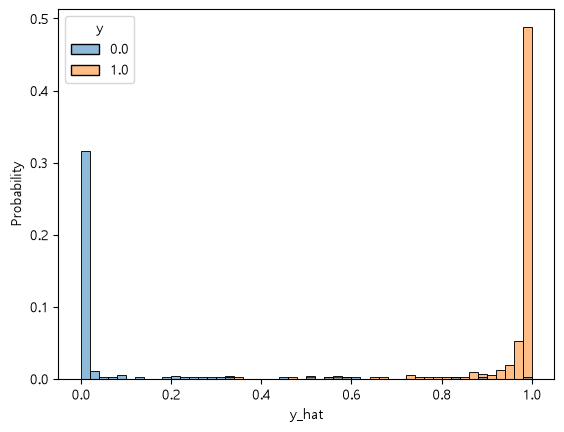

In [27]:
df = pd.DataFrame(
    torch.cat([y, probs], dim=1).detach().numpy(), # 정답과 예측값 열방향으로 합쳐, 텐서를 graph추적 삭제 후 numpy형태로 변환
    columns=["y", "y_hat"]
)

sns.histplot(df, x='y_hat',hue='y',bins=50,stat='probability')
plt.show()